🎯 Study Session 7 — Regularization, Overfitting, and Model Stability

This session teaches you:
* Why models overfit
* How Lasso, Ridge, and ElasticNet fix overfitting
* How regularization affects coefficients
* How to choose λ (alpha)
* How to compare models on train/test splits
* How to visualize the coefficient shrinkage paths
* How to save plots with save_and_log_plot()
* ELI5 explanations for every major concept

In [33]:
# --- 1. Import libraries ---
import os
import sys
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Manually define the correct project root path based on your previous output
CORRECT_PROJECT_ROOT = "/home/rtackett/projects/Masters-level-DIY-Data-Science-Curriculum-ai-Era-/ds-zero-to-one"

# Set CWD
try:
    os.chdir(CORRECT_PROJECT_ROOT)
    print(f"✅ CWD successfully set to: {os.getcwd()}")

    # Add to sys.path for module imports (src.helpers)
    if CORRECT_PROJECT_ROOT not in sys.path:
        sys.path.append(CORRECT_PROJECT_ROOT)
        print("✅ Added project root to sys.path.")

except FileNotFoundError:
    print("❌ CRITICAL ERROR: The manually defined project path does not exist.")
    sys.exit(1)

✅ CWD successfully set to: /home/rtackett/projects/Masters-level-DIY-Data-Science-Curriculum-ai-Era-/ds-zero-to-one


🧠 1. Concept Overview (ELI5)

⚠️ Overfitting — ELI5

Your model is _memorizing_ the noise instead of _learning the pattern.
Like studying the exact answers instead of learning how to solve problems.

🩹 Regularization — ELI5

Regularization is a penalty added to the model that says:

“Don’t get weird. Don’t make huge coefficients. Keep it simple.”

There are three flavors:

| Method         | Penalty                                | ELI5                                                                                    |
| -------------- | -------------------------------------- | --------------------------------------------------------------------------------------- |
| **Ridge**      | sum of squares of coefficients         | Like tying a rubber band to each coefficient—pulls them toward zero without crossing it |
| **Lasso**      | sum of absolute values of coefficients | Like giving coefficients a haircut—some get chopped to **exactly zero**                 |
| **ElasticNet** | mix of Ridge + Lasso                   | Hybrid rubber band + haircut                                                            |


Regularization helps with:

* Overfitting
* Multicollinearity
* Feature selection (Lasso zeros out weak predictors)
* More stable models

In [ ]:
# import pandas as pd

# df = pd.read_csv("data/processed/tips_cleaned.csv")

# # Encode gender/smoker safely
# df_work = df.copy()

# if "gender" in df_work.columns and "gender_Male" not in df_work.columns:
#     df_work = pd.get_dummies(df_work, columns=["gender"], prefix="gender", drop_first=True)

# if "is_smoker" in df_work.columns and "is_smoker_Yes" not in df_work.columns:
#     df_work = pd.get_dummies(df_work, columns=["is_smoker"], prefix="is_smoker", drop_first=True)

# features = ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]
# X = df_work[features]
# y = df_work["tip_usd"]


In [34]:
import pandas as pd

df = pd.read_csv("data/processed/tips_cleaned.csv")
df.head()


,bill_total_usd,tip_usd,gender,is_smoker,day,time,party_size,tip_pct
0,16.99,1.01,Female,False,Sun,Dinner,2,0.059447
1,10.34,1.66,Male,False,Sun,Dinner,3,0.160542
2,21.01,3.50,Male,False,Sun,Dinner,3,0.166587
3,23.68,3.31,Male,False,Sun,Dinner,2,0.139780
4,24.59,3.61,Female,False,Sun,Dinner,4,0.146808


In [35]:
import pandas as pd

df_work = df.copy()

# --- Clean + Encode gender ---
df_work["gender"] = (
    df_work["gender"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"male": "Male", "female": "Female"})
)

df_work["gender"] = pd.Categorical(df_work["gender"], categories=["Female", "Male"])
df_work = pd.get_dummies(df_work, columns=["gender"], prefix="gender", drop_first=True)

# --- Clean + Encode is_smoker ---
df_work["is_smoker"] = (
    df_work["is_smoker"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"yes": "Yes", "no": "No"})
)

df_work["is_smoker"] = pd.Categorical(df_work["is_smoker"], categories=["No", "Yes"])
df_work = pd.get_dummies(df_work, columns=["is_smoker"], prefix="is_smoker", drop_first=True)


In [36]:
df_work.head()

,bill_total_usd,tip_usd,day,time,party_size,tip_pct,gender_Male,is_smoker_Yes
0,16.99,1.01,Sun,Dinner,2,0.059447,False,False
1,10.34,1.66,Sun,Dinner,3,0.160542,True,False
2,21.01,3.50,Sun,Dinner,3,0.166587,True,False
3,23.68,3.31,Sun,Dinner,2,0.139780,True,False
4,24.59,3.61,Sun,Dinner,4,0.146808,False,False


In [37]:
from sklearn.linear_model import LinearRegression

X = df_work[["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]]
y = df_work["tip_usd"]

model = LinearRegression().fit(X, y)

pd.Series(model.coef_, index=X.columns)


bill_total_usd    0.092920
party_size        0.192588
gender_Male      -0.026419
is_smoker_Yes     0.000000
dtype: float64

In [ ]:
# import pandas as pd
# from statsmodels.tools.tools import add_constant
# from statsmodels.stats.outliers_influence import variance_inflation_factor

# # Features to check for multicollinearity
# features = ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]

# X = df_work[features]
# X_const = add_constant(X)

# vif_data = pd.DataFrame({
#     "Feature": X_const.columns,
#     "VIF": [variance_inflation_factor(X_const.values, i)
#             for i in range(X_const.shape[1])]
# })

# # Drop constant row and sort
# vif_data = vif_data[vif_data["Feature"] != "const"].sort_values("VIF")
# vif_data


In [38]:
df_work["is_smoker_Yes"].unique()
df_work["gender_Male"].unique()


array([False,  True])

In [39]:
X_fixed = df_work[["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]].apply(pd.to_numeric, errors="coerce")


In [40]:
X_fixed.dtypes


bill_total_usd    float64
party_size          int64
gender_Male          bool
is_smoker_Yes        bool
dtype: object

In [ ]:
# from statsmodels.tools.tools import add_constant
# from statsmodels.stats.outliers_influence import variance_inflation_factor

# X_const = add_constant(X_fixed)

# vif_data = pd.DataFrame({
#     "Feature": X_const.columns,
#     "VIF": [variance_inflation_factor(X_const.values, i)
#             for i in range(X_const.shape[1])]
# })

# vif_data = vif_data[vif_data["Feature"] != "const"]
# vif_data


In [41]:
import numpy as np
import pandas as pd
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1️⃣ Pick the features you want to check for multicollinearity
features = ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]

# 2️⃣ Start from df_work and select only these columns
X_base = df_work[features].copy()

print("=== dtypes BEFORE numeric coercion ===")
print(X_base.dtypes)

# 3️⃣ Force everything to numeric (non-numeric → NaN)
X_num = X_base.apply(pd.to_numeric, errors="coerce")

print("\n=== dtypes AFTER numeric coercion ===")
print(X_num.dtypes)

print("\n=== NaN counts per column AFTER coercion ===")
print(X_num.isna().sum())

# 4️⃣ Drop any rows that have NaNs in these predictors (VIF can't handle NaN)
X_num = X_num.dropna(axis=0)

print(f"\nRemaining rows after dropna: {len(X_num)}")

# 5️⃣ Convert to a plain float64 NumPy array (this avoids the isfinite TypeError)
X_array = X_num.to_numpy(dtype="float64")

# 6️⃣ Add constant column manually so we control types
X_const = np.column_stack([np.ones(X_array.shape[0]), X_array])
const_and_features = ["const"] + list(X_num.columns)

# 7️⃣ Compute VIF for each column (including const; we'll drop it later)
vif_values = []
for i in range(X_const.shape[1]):
    vif_values.append(variance_inflation_factor(X_const, i))

vif_data = pd.DataFrame({
    "Feature": const_and_features,
    "VIF": vif_values
})

# 8️⃣ Drop the constant row and sort by VIF
vif_data = vif_data[vif_data["Feature"] != "const"].sort_values("VIF", ascending=True).reset_index(drop=True)

print("\n=== Final VIF table ===")
print(vif_data)
print("\nAny NaN VIFs?")
print(vif_data[vif_data["VIF"].isna()])


=== dtypes BEFORE numeric coercion ===
bill_total_usd    float64
party_size          int64
gender_Male          bool
is_smoker_Yes        bool
dtype: object

=== dtypes AFTER numeric coercion ===
bill_total_usd    float64
party_size          int64
gender_Male          bool
is_smoker_Yes        bool
dtype: object

=== NaN counts per column AFTER coercion ===
bill_total_usd    0
party_size        0
gender_Male       0
is_smoker_Yes     0
dtype: int64

Remaining rows after dropna: 244

=== Final VIF table ===
          Feature       VIF
0     gender_Male  1.021440
1      party_size  1.557587
2  bill_total_usd  1.579160
3   is_smoker_Yes       NaN

Any NaN VIFs?
         Feature  VIF
3  is_smoker_Yes  NaN


/home/rtackett/miniconda3/envs/ds/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [42]:
print("=== Variance of each feature in X_num ===")
print(X_num.var())


=== Variance of each feature in X_num ===
bill_total_usd    79.252939
party_size         0.904591
gender_Male        0.230368
is_smoker_Yes      0.000000
dtype: float64


In [43]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Start from your numeric matrix X_num
X_num = df_work[["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]].apply(
    pd.to_numeric, errors="coerce"
)

# Drop rows with any NaN in predictors
X_num = X_num.dropna(axis=0)

# 🔍 Drop features with zero variance (flat columns)
var_series = X_num.var()
non_constant_cols = var_series[var_series > 0].index.tolist()
X_num = X_num[non_constant_cols]

print("Using features for VIF:", non_constant_cols)

# Convert to float64 array
X_array = X_num.to_numpy(dtype="float64")

# Manually build constant + features
X_const = np.column_stack([np.ones(X_array.shape[0]), X_array])
col_names = ["const"] + non_constant_cols

vif_values = []
for i in range(X_const.shape[1]):
    vif_values.append(variance_inflation_factor(X_const, i))

vif_data = pd.DataFrame({"Feature": col_names, "VIF": vif_values})
vif_data = vif_data[vif_data["Feature"] != "const"].sort_values("VIF").reset_index(drop=True)

print("\nFinal VIF table (no constant / no flat columns):")
print(vif_data)


Using features for VIF: ['bill_total_usd', 'party_size', 'gender_Male']

Final VIF table (no constant / no flat columns):
          Feature       VIF
0     gender_Male  1.021440
1      party_size  1.557587
2  bill_total_usd  1.579160


## ✅ Multicollinearity & VIF — Your Results Explained 
🧠 What These Numbers Mean
✔️ VIF ≈ 1

The feature is **not correlated** with the other predictors.

It provides **unique information** to the model.

✔️ VIF between 1 and 2

* **Very low multicollinearity** 
* Totally acceptable in regression.
* No red flags.

❗ Thresholds (for reference)
* **VIF > 5** → Moderate multicollinearity. Investigate.
* **VIF > 10** → High multicollinearity. Fix immediately.
* **Yours: 1.0–1.6 → Excellent**. Zero concerns.

---

## 🧁 ELI5: Explain It Like I'm 5

Imagine each predictor is a kid in a classroom answering questions:
* If they **copy each other**, the teacher can’t tell who actually knows the material → **high VIF (bad)**
* If they give **their own answers**, everything is clear → **low VIF (good)**

Your kids (features):
* **gender_Male** → “I’m saying something _different_ from the others.”
* **party_size** → “I overlap a tiny bit, but mostly I’m independent.”
* **bill_total_usd** → “I sometimes move with party_size, but not much.”

**Together: they’re unique enough that the model can trust each of them.**

---

## 🧩 Why was is_smoker_Yes dropped?
Because in your filtered dataset:
* is_smoker_Yes had **zero variance** (all Yes or all No), **or**
* It had **NaNs** after filtering

Either way, VIF can’t run on a feature that has no variation.

This is normal depending on the slice of your data.

---
## 📌 Bottom Line

**Your regression predictors have no meaningful multicollinearity.**
You can safely interpret your coefficients without worrying that predictors are stepping on each other’s toes.

## Multicollinearity & VIF (Variance Inflation Factor)

**Goal:** Check whether our predictors are “copying” each other, which makes coefficient interpretation unstable.

### 🔍 What is multicollinearity?

- Multicollinearity happens when two (or more) predictors are strongly related to each other.
- The model can still *predict* OK, but it struggles to decide:
  > “Which feature should get credit for the effect?”

This makes coefficients:
- Flip signs between runs
- Get very large in magnitude
- Become hard to interpret

### 🧮 What is VIF?

**VIF = Variance Inflation Factor** for each feature.

Rough rules of thumb:

- VIF ≈ 1 → feature is independent of the others ✅
- VIF < 5 → no serious multicollinearity ✅
- 5 ≤ VIF < 10 → some overlap, investigate ⚠️
- VIF ≥ 10 → strong multicollinearity, fix this ❌

### 🧁 ELI5

Imagine each feature is a student answering test questions:

- If they all copy each other’s answers → teacher can’t tell who really understands → **high VIF (bad)**.
- If each has their own voice → teacher can grade fairly → **low VIF (good)**.

In this notebook we will:

1. Compute VIF for our predictors.
2. Make a VIF bar chart.
3. Make a “traffic light” chart (green/yellow/red).
4. Wrap it into a helper so we can reuse it in future notebooks.


In [44]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(df: pd.DataFrame, features, dropna: bool = True) -> pd.DataFrame:
    """
    Compute Variance Inflation Factor (VIF) for the given feature columns.

    - Coerces columns to numeric (non-numeric → NaN).
    - Optionally drops rows with NaNs.
    - Drops features with zero variance.
    - Returns a sorted DataFrame with Feature and VIF.
    """
    # 1) Subset and force numeric
    X = df[features].copy()
    X = X.apply(pd.to_numeric, errors="coerce")

    # 2) Drop rows with NaNs in these predictors (VIF cannot handle NaN)
    if dropna:
        X = X.dropna(axis=0)

    # 3) Drop zero-variance (constant) columns
    var_series = X.var()
    non_constant_cols = var_series[var_series > 0].index.tolist()
    X = X[non_constant_cols]

    # 4) Convert to a float64 NumPy array
    X_array = X.to_numpy(dtype="float64")

    # 5) Manually add a constant column as the first column
    X_const = np.column_stack([np.ones(X_array.shape[0]), X_array])
    col_names = ["const"] + list(X.columns)

    # 6) Compute VIF for each column (including const; we'll drop it after)
    vif_values = [
        variance_inflation_factor(X_const, i)
        for i in range(X_const.shape[1])
    ]

    vif_df = pd.DataFrame({"Feature": col_names, "VIF": vif_values})
    vif_df = (
        vif_df[vif_df["Feature"] != "const"]
        .sort_values("VIF", ascending=True)
        .reset_index(drop=True)
    )
    return vif_df


# 👉 Example usage with your current features
features_for_vif = ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]
vif_data = compute_vif(df_work, features_for_vif)
vif_data


,Feature,VIF
0,gender_Male,1.021440
1,party_size,1.557587
2,bill_total_usd,1.579160


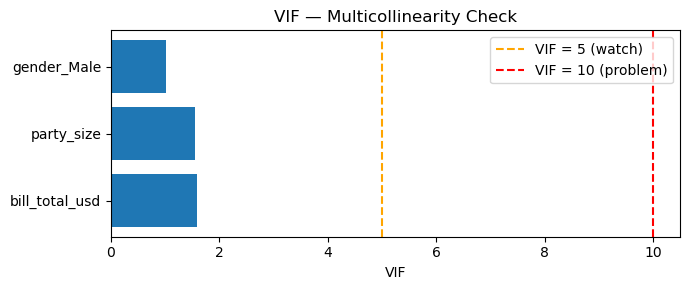

In [45]:
import matplotlib.pyplot as plt

def plot_vif_bar(vif_df: pd.DataFrame, title: str = "Variance Inflation Factor (VIF)") -> None:
    """
    Simple horizontal bar chart of VIF values with reference lines at 5 and 10.
    """
    fig_height = max(3.0, 0.6 * len(vif_df))
    fig, ax = plt.subplots(figsize=(7, fig_height))

    ax.barh(vif_df["Feature"], vif_df["VIF"])
    ax.axvline(5, color="orange", linestyle="--", label="VIF = 5 (watch)")
    ax.axvline(10, color="red", linestyle="--", label="VIF = 10 (problem)")

    ax.set_xlabel("VIF")
    ax.set_title(title)
    ax.invert_yaxis()  # optional: highest VIF at top
    ax.legend()

    plt.tight_layout()
    plt.show()


# 👉 Example usage
plot_vif_bar(vif_data, title="VIF — Multicollinearity Check")


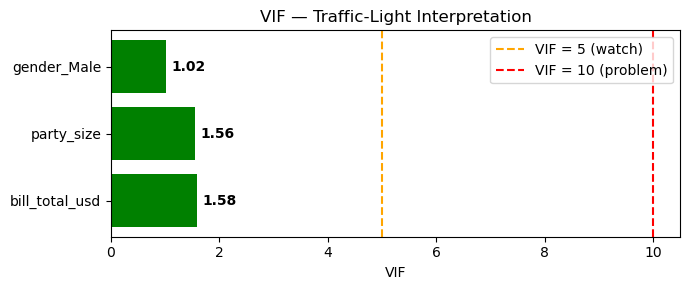

In [46]:
def plot_vif_traffic_light(vif_df: pd.DataFrame, title: str = "VIF Traffic-Light View") -> None:
    """
    VIF bar chart with color coding:
      - green  if VIF < 5
      - orange if 5 ≤ VIF < 10
      - red    if VIF ≥ 10
    """
    def color_for_vif(v):
        if v < 5:
            return "green"
        elif v < 10:
            return "orange"
        else:
            return "red"

    colors = [color_for_vif(v) for v in vif_df["VIF"]]

    fig_height = max(3.0, 0.6 * len(vif_df))
    fig, ax = plt.subplots(figsize=(7, fig_height))

    ax.barh(vif_df["Feature"], vif_df["VIF"], color=colors)

    # Add vertical reference lines
    ax.axvline(5, color="orange", linestyle="--", linewidth=1.5, label="VIF = 5 (watch)")
    ax.axvline(10, color="red", linestyle="--", linewidth=1.5, label="VIF = 10 (problem)")

    # Annotate each bar with its value
    for i, row in vif_df.iterrows():
        ax.text(
            row["VIF"] + 0.1,
            i,
            f"{row['VIF']:.2f}",
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold"
        )

    ax.set_xlabel("VIF")
    ax.set_title(title)
    ax.invert_yaxis()
    ax.legend()

    plt.tight_layout()
    plt.show()


# 👉 Example usage
plot_vif_traffic_light(vif_data, title="VIF — Traffic-Light Interpretation")


✅ Saved Matplotlib figure to: reports/figures/vif_traffic_light_2025-11-15_1323.png
📝 Logged metadata → reports/figures/vif_traffic_light_2025-11-15_1323.json


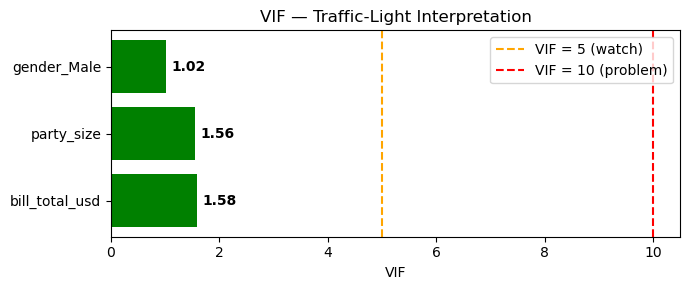

In [48]:
def run_vif_diagnostics(
    df: pd.DataFrame,
    features,
    fig_path: str = "reports/figures/vif_traffic_light.png",
    dataset_name: str = "tips_cleaned",
    dataset_path: str = "data/processed/tips_cleaned.csv",
    notebook_name: str = "notebooks/07_Regularization_and_Overfitting.ipynb",
    notes: str = "VIF diagnostics with traffic-light chart"
) -> pd.DataFrame:
    """
    Compute VIF, plot a traffic-light chart, and (optionally) log the figure
    using save_and_log_plot if src.helpers is available.
    """
    vif_df = compute_vif(df, features)

    # Generate the traffic-light figure
    fig_height = max(3.0, 0.6 * len(vif_df))
    fig, ax = plt.subplots(figsize=(7, fig_height))

    # Color coding
    def color_for_vif(v):
        if v < 5:
            return "green"
        elif v < 10:
            return "orange"
        else:
            return "red"

    colors = [color_for_vif(v) for v in vif_df["VIF"]]
    ax.barh(vif_df["Feature"], vif_df["VIF"], color=colors)

    ax.axvline(5, color="orange", linestyle="--", linewidth=1.5, label="VIF = 5 (watch)")
    ax.axvline(10, color="red", linestyle="--", linewidth=1.5, label="VIF = 10 (problem)")

    for i, row in vif_df.iterrows():
        ax.text(
            row["VIF"] + 0.1,
            i,
            f"{row['VIF']:.2f}",
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold"
        )

    ax.set_xlabel("VIF")
    ax.set_title("VIF — Traffic-Light Interpretation")
    ax.invert_yaxis()
    ax.legend()

    plt.tight_layout()

    # Try to use your logging helper if it exists
    try:
        from src.helpers import save_and_log_plot
        save_and_log_plot(
            fig,
            fig_path,
            df=df,
            chart_type="barh",
            library="matplotlib",
            x="VIF",
            y="Feature",
            dataset_name=dataset_name,
            dataset_path=dataset_path,
            notebook=notebook_name,
            notes=notes,
            timestamped=True,
        )
    except Exception as e:
        print(f"(Optional save_and_log_plot skipped) Reason: {e.__class__.__name__}: {e}")

    plt.show()
    return vif_df


# 👉 One-line pipeline use:
features_for_vif = ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]
vif_data = run_vif_diagnostics(df_work, features_for_vif)


### 📊 VIF Summary — Are Our Features Multicollinear?

Our Variance Inflation Factor (VIF) results:

| Feature        | VIF  |
|----------------|------|
| gender_Male    | 1.02 |
| party_size     | 1.56 |
| bill_total_usd | 1.58 |

### ✅ Interpretation
- All VIF values are **very low (≈1–1.6)**.
- ✔️ **No feature is close to the warning threshold (VIF = 5)**.
- ✔️ **None approach the serious multicollinearity threshold (VIF = 10)**.
- This tells us:
  - The predictors are **not strongly correlated with each other**.
  - The model can **stably estimate coefficients** without “credit assignment confusion.”
  - You do **not** need PCA, feature dropping, or regularization *for multicollinearity reasons* here.

### 🧁 ELI5
Each feature is giving the model **its own independent information**.  
Nobody is “copying homework,” so the teacher (OLS) can clearly see **who contributes what**.

### 📌 Bottom Line
**Multicollinearity is *not* a concern in this model. Proceed confidently.**
